# Does Innovation Open Export Doors? Nigerian firms, 2014 to 2026
**Standalone notebook.** Everything needed to reproduce the analysis is in this one file: data loading, models, tables and figure.
No other project files are required.

**What you need**
1. Python 3.10+ with `pandas numpy scipy statsmodels patsy matplotlib pyreadstat` (conda: `conda install -c conda-forge pandas numpy scipy statsmodels patsy matplotlib pyreadstat`).
2. The three World Bank survey files in one folder (free, registration required at <https://www.enterprisesurveys.org>):
   `Nigeria-2014-full-data.dta`, `Nigeria-2025-full-data.dta`, `Nigeria-2026-AI-followup.dta`.
   ZIP downloads are fine, including a ZIP saved with a `.dta` extension: they are unpacked automatically.
3. Set `DATA_DIR` in the next cell (default: the folder of this notebook, or a `data` subfolder if it exists).

All estimates are **associations**, not causal effects. Survey data are not included and must not be redistributed.

## 1. Setup

In [1]:
# ---- Packages required (install once, e.g. from conda-forge) -------------------------------------
# conda install -c conda-forge python=3.11 "pandas>=2.0" numpy "scipy>=1.11" "statsmodels>=0.14" patsy matplotlib pyreadstat jupyterlab ipykernel
#   python       3.10 or newer
#   pandas       >=2.0   data tables
#   numpy                arrays and maths
#   scipy        >=1.11  normal distribution for probit and bivariate probit
#   statsmodels  >=0.14  probit models and the bivariate-probit likelihood
#   patsy                model formulas such as C(legal) + training
#   matplotlib           the figure
#   pyreadstat           reads the Stata .dta files
#   jupyterlab, ipykernel   only needed to run this notebook
# ---------------------------------------------------------------------------------------------------
from pathlib import Path                                  # standard library: file paths
import warnings, zipfile                                  # standard library: silence warnings, unpack ZIP downloads
import numpy as np                                        # arrays and maths
import pandas as pd                                       # data tables
import patsy                                              # builds design matrices from formulas
import pyreadstat                                         # reads .dta files
import statsmodels.api as sm                              # probit and GLM models
from scipy import stats                                   # normal distribution functions
from statsmodels.base.model import GenericLikelihoodModel # base class for the bivariate probit
from statsmodels.tools.numdiff import approx_fprime       # numerical derivatives for standard errors
import matplotlib.pyplot as plt                           # plotting

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

# >>> Folder holding the three survey files. Default: ./data if it exists, else the notebook folder.
DATA_DIR = Path("data") if Path("data").exists() else Path(".")
OUT_DIR = Path("output")            # tables (CSV) and the figure are written here
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
RAW = DATA_DIR
print("Reading data from:", RAW.resolve())

Reading data from: data


## 2. Data loading and variable construction
Survey answer codes: 1 = Yes, 2 = No, negatives (-9 don't know, -8 refusal, ...) = missing. Innovation = new product, new process or R&D (asked in both 2014 and 2025). Exporting = any direct or indirect export sales.

In [2]:
def _read(name):
    """Read a Stata file from data/raw. World Bank downloads are sometimes a ZIP saved with a .dta
    extension (or a .zip); both are unpacked automatically into data/interim/."""
    path = RAW / name
    if not path.exists():
        found = sorted(p.name for p in RAW.glob("*")) if RAW.exists() else []
        raise FileNotFoundError(
            f"Missing {path}.\nExpected files in DATA_DIR: Nigeria-2014-full-data.dta, Nigeria-2025-full-data.dta, "
            f"Nigeria-2026-AI-followup.dta (set DATA_DIR in the setup cell).\nFound: {found}")
    if zipfile.is_zipfile(path):
        cache = OUT_DIR / "_unzipped" / path.stem
        cache.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(path) as z:
            dta = [n for n in z.namelist() if n.lower().endswith(".dta")]
            if not dta:
                raise ValueError(f"{path} is a ZIP with no .dta file inside")
            z.extract(dta[0], cache)
        path = cache / dta[0]
    df, _ = pyreadstat.read_dta(str(path), apply_value_formats=False)
    return df


def _yes(s):
    """1/2 survey answer -> 1.0/0.0, anything else -> NaN."""
    s = s.where(s.isin([1, 2]))
    return (s == 1).astype(float).where(s.notna())


def _clean(s):
    s = pd.to_numeric(s, errors="coerce")
    return s.where(s >= 0)


def _legal_form(code_map, s):
    return s.map(code_map)


def load_2014():
    d = _read("Nigeria-2014-full-data.dta")
    o = pd.DataFrame({"idstd": d.idstd, "year": 2014})
    # innovation types (last three years)
    o["product"] = _yes(d.h1)
    o["process"] = _yes(d.h3)
    o["organizational"] = _yes(d.h5)
    o["marketing"] = _yes(d.h6)
    o["rnd"] = _yes(d.h7)
    # 2018 paper's definition reproduces 1,897 innovators exactly:
    # any of h1, h3, h4a, h4b, h5, h6, h7 == 1
    o["innov_paper"] = np.any([d[c] == 1 for c in ["h1", "h3", "h4a", "h4b", "h5", "h6", "h7"]], axis=0).astype(float)
    # exports: any direct or indirect export sales
    o["export_any"] = ((d.d3b > 0) | (d.d3c > 0)).astype(float)
    o["export_direct"] = (d.d3c > 0).astype(float)
    o["export_share"] = _clean(d.d3b).fillna(0) + _clean(d.d3c).fillna(0)
    o.loc[(d.d3b < 0) & (d.d3c < 0), "export_share"] = np.nan
    # controls
    o["training"] = _yes(d.l10)
    o["legal"] = d.b1.map({3: "sole", 1: "shareholder", 2: "shareholder", 4: "partnership", 5: "partnership"})
    o["log_emp"] = np.log(_clean(d.l1).where(lambda s: s > 0))
    o["age"] = 2014 - _clean(d.b5).where(lambda s: s > 1800)
    o["female_owner"] = _yes(d.b4)
    o["mgr_exp"] = _clean(d.b7)
    o["foreign_owned"] = (_clean(d.b2b) > 0).astype(float).where(_clean(d.b2b).notna()) if "b2b" in d else np.nan
    o["quality_cert"] = _yes(d.b8)
    o["foreign_tech"] = _yes(d.e6)   # asked of a subset of firms in 2014
    o["export_zone"] = d.ngb1.where(d.ngb1.isin([1, 2, 3])).map({3: 1, 2: 2, 1: 3})  # 1 neither, 2 industrial, 3 EPZ
    o["region"] = d.a2
    o["sector"] = d.a4a
    o["weight"] = d.wmedian
    return o


def load_2025():
    d = _read("Nigeria-2025-full-data.dta")
    o = pd.DataFrame({"idstd": d.idstd, "year": 2025})
    o["product"] = _yes(d.h1)
    o["process"] = _yes(d.h5)
    o["rnd"] = _yes(d.h8)  # R&D spending in last fiscal year
    o["export_any"] = ((d.d3b > 0) | (d.d3c > 0)).astype(float)
    o["export_direct"] = (d.d3c > 0).astype(float)
    o["export_share"] = _clean(d.d3b).fillna(0) + _clean(d.d3c).fillna(0)
    o.loc[(d.d3b < 0) & (d.d3c < 0), "export_share"] = np.nan
    o["training"] = _yes(d.l10)
    o["legal"] = d.b1.map({3: "sole", 1: "shareholder", 2: "shareholder", 4: "partnership", 5: "partnership"})
    o["log_emp"] = np.log(_clean(d.l1).where(lambda s: s > 0))
    o["age"] = 2025 - _clean(d.b5).where(lambda s: s > 1800)
    o["female_owner"] = _yes(d.b4)
    o["mgr_exp"] = _clean(d.b7)
    o["foreign_owned"] = (_clean(d.b2b) > 0).astype(float).where(_clean(d.b2b).notna())
    o["quality_cert"] = _yes(d.b8)
    o["foreign_tech"] = _yes(d.e6)
    o["owner_manager"] = _yes(d.b3a)
    o["panel_2025"] = d.panel
    o["region"] = d.a2
    o["sector"] = d.a4a
    o["weight"] = d.wmedian
    return o


def add_innovation_indices(df, types):
    """innov_any / n_types / combined (>=2 types) from the listed 0/1 columns.
    Firms missing every listed answer stay missing."""
    x = df[types]
    df["n_types"] = x.sum(axis=1, min_count=1)
    df["innov_any"] = (df.n_types > 0).astype(float).where(df.n_types.notna())
    df["single_only"] = (df.n_types == 1).astype(float).where(df.n_types.notna())
    df["combined"] = (df.n_types >= 2).astype(float).where(df.n_types.notna())
    return df


def comparable(df14, df25):
    """Cross-year comparable innovation measure: product, process or R&D (asked in both surveys)."""
    types = ["product", "process", "rnd"]
    return add_innovation_indices(df14.copy(), types), add_innovation_indices(df25.copy(), types)


def load_ai_followup(baseline25):
    """2026 AI follow-up (CATI, Jan-Mar 2026, 777 of the 1,043 baseline firms), merged on idstd to the 2025 baseline.
    Weight `weight` is the follow-up weight `wt` (baseline weight x stratum non-response adjustment)."""
    a = _read("Nigeria-2026-AI-followup.dta")
    base = baseline25.drop(columns=["weight"])
    # baseline interview month, for checking whether AI adoption pre-dates the baseline survey
    raw = _read("Nigeria-2025-full-data.dta")[["idstd", "a14y", "a14m"]]
    base = base.merge(raw, on="idstd", how="left")
    out = a[["idstd", "wt", "ai_adopt1", "ai_b2a1", "ai_b2a2", "ai_b2a3", "ai_b2a4", "ai_b2a5", "ai_b2a6",
             "ai_b4a1", "ai_b5a", "ai_b1b", "ai_b1a3", "ai_b6f"]].rename(columns={"wt": "weight"})
    m = out.merge(base, on="idstd", how="left", validate="1:1")
    m["ai_adopt"] = m.ai_adopt1.astype(float)
    for c in ["ai_b2a1", "ai_b2a2", "ai_b2a3", "ai_b2a4", "ai_b2a5", "ai_b2a6", "ai_b6f", "ai_b1a3"]:
        m[c] = _yes(m[c])
    m["ai_rnd_use"] = _yes(m.ai_b4a1)                      # asked of adopters only
    m["computer_share"] = _clean(m.ai_b1b)
    m["ai_first_yyyymm"] = _clean(m.ai_b5a)
    m["baseline_yyyymm"] = m.a14y * 100 + m.a14m
    m["ai_before_baseline"] = (m.ai_first_yyyymm < m.baseline_yyyymm).astype(float).where(m.ai_first_yyyymm.notna())
    return data_add_innov(m)


def data_add_innov(m):
    return add_innovation_indices(m, ["product", "process", "rnd"])

## 3. Models
Probit with robust standard errors and **average marginal effects** (delta-method SEs, optional survey weights), and a recursive bivariate probit (own likelihood, exploratory).

In [3]:
_PHI = stats.norm.cdf
_phi = stats.norm.pdf


# ---------------------------------------------------------------- probit + AME
def fit_probit(df, y, rhs, weight=None):
    """Probit of y on rhs (patsy formula RHS). Robust (HC1-style sandwich) SEs.

    weight: column name of survey weights (rescaled to mean 1) or None.
    Returns dict with result, design info and the AME table (delta-method SEs).
    """
    cols = [y] + ([weight] if weight else [])
    data = df.copy()
    yv, X = patsy.dmatrices(f"{y} ~ {rhs}", data, return_type="dataframe", NA_action="drop")
    idx = X.index
    w = None
    if weight:
        w = data.loc[idx, weight].astype(float)
        w = w / w.mean()
    mod = sm.GLM(yv.iloc[:, 0], X, family=sm.families.Binomial(link=sm.families.links.Probit()),
                 freq_weights=w if w is not None else None)
    res = mod.fit(cov_type="HC0" if w is not None else "HC1")
    ame = _ame_table(res, X, w, yv.columns[0])
    return {"res": res, "X": X, "n": len(idx), "ame": ame}


def _ame_from_params(params, X, w, is_bin):
    xb = X.values @ params
    out = []
    wts = np.ones(len(X)) if w is None else w.values
    for j, col in enumerate(X.columns):
        if col == "Intercept":
            out.append(np.nan)
            continue
        if is_bin[j]:
            x1, x0 = X.values.copy(), X.values.copy()
            x1[:, j], x0[:, j] = 1, 0
            eff = _PHI(x1 @ params) - _PHI(x0 @ params)
        else:
            eff = _phi(xb) * params[j]
        out.append(np.average(eff, weights=wts))
    return np.array(out)


def _ame_table(res, X, w, yname):
    is_bin = [set(np.unique(X[c])) <= {0.0, 1.0} for c in X.columns]
    params = res.params.values
    est = _ame_from_params(params, X, w, is_bin)
    jac = approx_fprime(params, lambda p: _ame_from_params(p, X, w, is_bin), centered=True)
    cov = res.cov_params().values
    se = np.sqrt(np.clip(np.einsum("ij,jk,ik->i", jac, cov, jac), 0, None))
    t = est / se
    tab = pd.DataFrame({"ame": est, "se": se, "z": t, "p": 2 * (1 - _PHI(np.abs(t)))}, index=X.columns)
    return tab.drop(index="Intercept")


def stars(p):
    return "***" if p < .01 else "**" if p < .05 else "*" if p < .10 else ""


def fmt_ame(tab, keep=None):
    t = tab if keep is None else tab.loc[[k for k in keep if k in tab.index]]
    return t.assign(ame_fmt=lambda d: d.ame.map("{:+.3f}".format) + d.p.map(stars),
                    se_fmt=lambda d: "(" + d.se.map("{:.3f}".format) + ")")


# ------------------------------------------------- recursive bivariate probit
def _bvn_cdf(h, k, rho, n_nodes=64):
    """P(Z1<=h, Z2<=k) for standard bivariate normal with correlation rho (array h,k; scalar rho).
    Phi2 = Phi(h)Phi(k) + integral_0^rho phi2(h,k;t) dt, by Gauss-Legendre (accurate for |rho|<~0.97)."""
    x, wq = np.polynomial.legendre.leggauss(n_nodes)
    t = 0.5 * rho * (x + 1.0)              # nodes on [0, rho]
    wt = 0.5 * rho * wq
    h = np.asarray(h)[:, None]
    k = np.asarray(k)[:, None]
    dens = np.exp(-(h ** 2 - 2 * t * h * k + k ** 2) / (2 * (1 - t ** 2))) / (2 * np.pi * np.sqrt(1 - t ** 2))
    return _PHI(h[:, 0]) * _PHI(k[:, 0]) + dens @ wt


class RecursiveBiprobit(GenericLikelihoodModel):
    """y1 = 1[ z'g + u > 0 ]  (endogenous regressor equation, e.g. innovation)
       y2 = 1[ a*y1 + x'b + e > 0 ]  (outcome equation, e.g. exports);  corr(u,e) = rho.
    Params: g (kz), [a, b] (1+kx), atanh(rho)."""

    def __init__(self, y1, Z, y2, X, **kw):
        self.y1, self.y2 = np.asarray(y1, float), np.asarray(y2, float)
        self.Z, self.X = np.asarray(Z, float), np.asarray(X, float)
        self.kz, self.kx = self.Z.shape[1], self.X.shape[1]
        super().__init__(endog=self.y2, exog=self.X, **kw)
        self.nparams = self.kz + 1 + self.kx + 1

    def loglikeobs(self, p):
        g = p[: self.kz]
        a = p[self.kz]
        b = p[self.kz + 1: self.kz + 1 + self.kx]
        rho = np.tanh(p[-1])
        rho = np.clip(rho, -0.97, 0.97)
        q1, q2 = 2 * self.y1 - 1, 2 * self.y2 - 1
        u = self.Z @ g
        v = a * self.y1 + self.X @ b
        ll = np.empty(len(q1))
        for s in (-1.0, 1.0):              # observations share rho*s within each sign group
            m = (q1 * q2) == s
            if m.any():
                pr = _bvn_cdf(q1[m] * u[m], q2[m] * v[m], s * rho)
                ll[m] = np.log(np.clip(pr, 1e-300, None))
        return ll

    def fit_model(self, start=None, **kw):
        if start is None:
            start = np.zeros(self.nparams)
            g0 = sm.Probit(self.y1, self.Z).fit(disp=0).params
            xb = np.column_stack([self.y1, self.X])
            b0 = sm.Probit(self.y2, xb).fit(disp=0).params
            start = np.concatenate([g0, b0, [0.0]])
        return self.fit(start_params=start, method="bfgs", maxiter=500, disp=0, **kw)


def fit_biprobit(df, y_innov, y_out, z_terms, x_terms):
    """z_terms / x_terms: patsy RHS strings for the innovation and outcome equations (no intercept needed)."""
    used = [y_innov, y_out]
    Zm = patsy.dmatrix(z_terms, df, return_type="dataframe", NA_action="drop")
    Xm = patsy.dmatrix(x_terms, df, return_type="dataframe", NA_action="drop")
    idx = Zm.index.intersection(Xm.index).intersection(df[used].dropna().index)
    Zm, Xm, d = Zm.loc[idx], Xm.loc[idx], df.loc[idx]
    mod = RecursiveBiprobit(d[y_innov], Zm, d[y_out], Xm)
    res = mod.fit_model()
    kz, kx = Zm.shape[1], Xm.shape[1]
    p = res.params
    names = [f"innov_eq:{c}" for c in Zm.columns] + ["export_eq:innov"] + [f"export_eq:{c}" for c in Xm.columns] + ["atanh_rho"]
    tab = pd.DataFrame({"coef": p, "se": res.bse, "p": res.pvalues}, index=names)
    alpha = p[kz]
    b = p[kz + 1: kz + 1 + kx]
    xb = Xm.values @ b
    ate = float(np.mean(_PHI(xb + alpha) - _PHI(xb)))       # average effect of innovating on P(export)

    def ate_fn(pp):
        return np.array([np.mean(_PHI(Xm.values @ pp[kz + 1: kz + 1 + kx] + pp[kz]) - _PHI(Xm.values @ pp[kz + 1: kz + 1 + kx]))])

    jac = np.atleast_2d(approx_fprime(np.asarray(p, float), ate_fn, centered=True)).reshape(1, -1)
    cov = res.cov_params()
    cov = cov.values if hasattr(cov, "values") else cov
    ate_se = float(np.sqrt(max(float((jac @ cov @ jac.T).ravel()[0]), 0)))
    rho = float(np.tanh(p.iloc[-1] if hasattr(p, "iloc") else p[-1]))
    # Wald test of rho=0 (exogeneity of innovation)
    wald_p = float(tab.loc["atanh_rho", "p"])
    return {"table": tab, "ate": ate, "ate_se": ate_se, "rho": rho, "rho_p": wald_p, "n": len(idx),
            "converged": bool(res.mle_retvals.get("converged", True)), "llf": float(res.llf)}

## 4. Load the data

In [4]:
d14, d25 = load_2014(), load_2025()
c14, c25 = comparable(d14, d25)          # innovation = product | process | R&D in both years
CTRL = ("C(legal) + training + log_emp + age + female_owner + mgr_exp + quality_cert + foreign_owned"
        " + C(sector) + C(region)")
print("2014 firms:", len(c14), "| 2025 firms:", len(c25))

def say(*a):
    print(" ".join(str(x) for x in a))
def save(df, name):
    df.to_csv(OUT_DIR / "tables" / f"{name}.csv")
    return df

2014 firms: 2676 | 2025 firms: 1043


## 5. T1: descriptive shares

In [5]:
def wshare(df, col):
    m = df[col].notna()
    return np.average(df.loc[m, col], weights=df.loc[m, "weight"])

rows = []
for lab, df, cols in [
    ("2014", c14, ["innov_paper", "innov_any", "product", "process", "organizational", "marketing", "rnd", "export_any", "export_direct", "training"]),
    ("2025", c25, ["innov_any", "product", "process", "rnd", "export_any", "export_direct", "training"])]:
    for c in cols:
        rows.append({"year": lab, "variable": c, "n_valid": int(df[c].notna().sum()),
                     "unweighted_share": df[c].mean(), "weighted_share": wshare(df, c)})
t1 = save(pd.DataFrame(rows), "T1_descriptives")
display(t1.round(3))
print(f"2014 paper-definition innovators: {int(c14.innov_paper.sum())} of {len(c14)} (2018 paper: 1,897 of 2,676)")
print(f"2014 exporters (any direct/indirect sales): {int(c14.export_any.sum())} (2018 paper: 651)")

,year,variable,n_valid,unweighted_share,weighted_share
0,2014,innov_paper,2676,0.709,0.730
1,2014,innov_any,2635,0.608,0.607
2,2014,product,2610,0.498,0.527
3,2014,process,2613,0.497,0.498
4,2014,organizational,2615,0.397,0.365
5,2014,marketing,2621,0.524,0.492
6,2014,rnd,2596,0.174,0.138
7,2014,export_any,2676,0.239,0.163
8,2014,export_direct,2676,0.178,0.131
9,2014,training,2573,0.293,0.307


2014 paper-definition innovators: 1897 of 2676 (2018 paper: 1,897 of 2,676)
2014 exporters (any direct/indirect sales): 639 (2018 paper: 651)


## 6. T2: replication of the 2018 headline model on 2014 data
The 2018 paper reported an innovation marginal effect of +0.1034; the closest rebuild is lower.

In [6]:
c14p = c14.assign(innov=c14.innov_paper, export=c14.export_any)
f = fit_probit(c14p, "export", "innov + C(legal) + training + C(export_zone)")
t2 = save(fmt_ame(f["ame"]), "T2_replication_2014")
print("N =", f["n"])
display(t2[["ame", "se", "p"]].round(4))

N = 2424


,ame,se,p
C(legal)[T.shareholder],0.1557,0.0433,0.0003
C(legal)[T.sole],-0.0623,0.0266,0.0193
C(export_zone)[T.2.0],0.1870,0.0214,0.0000
C(export_zone)[T.3.0],0.2280,0.0403,0.0000
innov,0.0843,0.0187,0.0000
training,0.0301,0.0191,0.1152


## 7. T3: effect of innovation on exporting, 2014 vs 2025

,year,outcome,weights,n,ame,se,p
0,2014,export_any,unweighted,2018,0.0372,0.0173,0.0317
1,2014,export_any,weighted,2018,0.0304,0.0154,0.0480
2,2014,export_direct,unweighted,2018,0.0350,0.0154,0.0229
3,2014,export_direct,weighted,2018,0.0260,0.0138,0.0591
4,2025,export_any,unweighted,1000,0.0003,0.0156,0.9869
5,2025,export_any,weighted,1000,-0.0002,0.0142,0.9910
6,2025,export_direct,unweighted,1000,0.0154,0.0113,0.1732
7,2025,export_direct,weighted,1000,0.0279,0.0120,0.0203


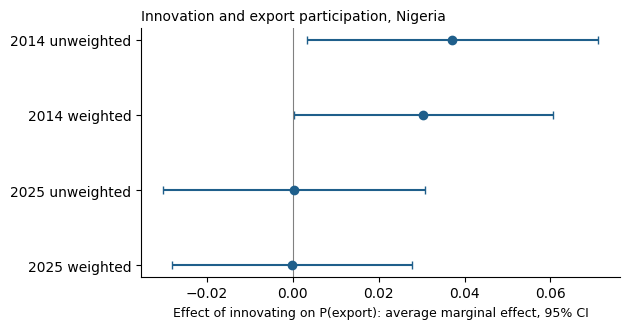

In [7]:
rows = []
for yr, df in [(2014, c14), (2025, c25)]:
    for yv in ["export_any", "export_direct"]:
        for wlab, w in [("unweighted", None), ("weighted", "weight")]:
            f = fit_probit(df, yv, f"innov_any + {CTRL}", weight=w)
            a = f["ame"].loc["innov_any"]
            rows.append({"year": yr, "outcome": yv, "weights": wlab, "n": f["n"], "ame": a.ame, "se": a.se, "p": a.p})
t3 = save(pd.DataFrame(rows), "T3_innovation_effect_by_year")
display(t3.round(4))

sub = t3[t3.outcome == "export_any"]
labels = [f"{int(r.year)} {r.weights}" for _, r in sub.iterrows()]
est = sub.ame.values; err = 1.96 * sub.se.values
y = np.arange(len(labels))[::-1]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.errorbar(est, y, xerr=err, fmt="o", color="#1f5f8b", capsize=3)
ax.axvline(0, color="grey", lw=0.8); ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Effect of innovating on P(export): average marginal effect, 95% CI", fontsize=9)
ax.set_title("Innovation and export participation, Nigeria", fontsize=10, loc="left")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); fig.savefig(OUT_DIR / "innovation_effect_by_year.png", dpi=160); plt.show()

## 8. T4: which type of innovation? T5: combined vs single

In [8]:
rows = []
for yr, df, types in [(2014, c14, ["product", "process", "organizational", "marketing", "rnd"]),
                      (2025, c25, ["product", "process", "rnd"])]:
    f = fit_probit(df, "export_any", f"{' + '.join(types)} + {CTRL}")
    for t in types:
        a = f["ame"].loc[t]
        rows.append({"year": yr, "type": t, "n": f["n"], "ame": a.ame, "se": a.se, "p": a.p})
    wt = f["res"].wald_test(", ".join(f"{types[0]} = {t}" for t in types[1:]), scalar=True)
    rows.append({"year": yr, "type": "Wald: all types equal (coef)", "n": f["n"], "ame": np.nan, "se": np.nan, "p": float(wt.pvalue)})
t4 = save(pd.DataFrame(rows), "T4_innovation_types"); display(t4.round(4))

rows = []
for yr, df in [(2014, c14), (2025, c25)]:
    f = fit_probit(df, "export_any", f"single_only + combined + {CTRL}")
    for t in ["single_only", "combined"]:
        a = f["ame"].loc[t]
        rows.append({"year": yr, "term": t + " (vs none)", "n": f["n"], "ame": a.ame, "se": a.se, "p": a.p})
    wt = f["res"].wald_test("single_only = combined", scalar=True)
    rows.append({"year": yr, "term": "Wald: combined = single (coef)", "n": f["n"], "ame": np.nan, "se": np.nan, "p": float(wt.pvalue)})
t5 = save(pd.DataFrame(rows), "T5_combined_vs_single"); display(t5.round(4))

,year,type,n,ame,se,p
0,2014,product,1979,0.0084,0.0205,0.6823
1,2014,process,1979,-0.0163,0.0220,0.4610
2,2014,organizational,1979,0.0396,0.0213,0.0627
3,2014,marketing,1979,0.0141,0.0208,0.4991
4,2014,rnd,1979,0.0856,0.0248,0.0006
5,2014,Wald: all types equal (coef),1979,NaN,NaN,0.0219
6,2025,product,995,0.0072,0.0190,0.7044
7,2025,process,995,0.0187,0.0201,0.3503
8,2025,rnd,995,-0.0119,0.0194,0.5389
9,2025,Wald: all types equal (coef),995,NaN,NaN,0.5264


,year,term,n,ame,se,p
0,2014,single_only (vs none),2018,0.0163,0.0237,0.4908
1,2014,combined (vs none),2018,0.0466,0.0192,0.0151
2,2014,Wald: combined = single (coef),2018,NaN,NaN,0.1732
3,2025,single_only (vs none),1000,-0.0136,0.0176,0.4394
4,2025,combined (vs none),1000,0.0182,0.0218,0.4058
5,2025,Wald: combined = single (coef),1000,NaN,NaN,0.1713


## 9. T6: recursive bivariate probit (exploratory)
Treats innovation as endogenous. The excluded instruments (foreign-licensed technology, staff training) are **debatable** (training may affect exports directly) and the estimates are unstable, so this is reported only for transparency.

In [9]:
BI_X = "log_emp + age + female_owner + mgr_exp + quality_cert + foreign_owned"
rows = []
for yr, df in [(2014, c14), (2025, c25)]:
    r = fit_biprobit(df, "innov_any", "export_any", f"{BI_X} + foreign_tech + training", BI_X)
    simple = fit_probit(df.loc[df[["foreign_tech", "training"]].notna().all(axis=1)], "export_any", f"innov_any + {BI_X}")
    rows.append({"year": yr, "n": r["n"], "converged": r["converged"], "biprobit_ATE_innov": r["ate"], "se": r["ate_se"],
                 "rho": r["rho"], "p_rho=0": r["rho_p"], "probit_AME_same_sample": simple["ame"].loc["innov_any", "ame"]})
    save(r["table"], f"T6_biprobit_coefficients_{yr}")
t6 = save(pd.DataFrame(rows), "T6_biprobit_summary"); display(t6.round(4))

,year,n,converged,biprobit_ATE_innov,se,rho,p_rho=0,probit_AME_same_sample
0,2014,856,True,0.3608,0.0737,-0.7207,0.0153,0.0706
1,2025,999,True,0.1000,0.1110,-0.3489,0.3895,0.0183


## 10. T7: did the innovation effect change between 2014 and 2025?

In [10]:
pool = pd.concat([c14.assign(y25=0.0), c25.assign(y25=1.0)], ignore_index=True)
pool["legal"] = pool["legal"].astype(object)
f = fit_probit(pool.assign(inn_y25=pool.innov_any * pool.y25), "export_any",
               "innov_any + inn_y25 + y25 + C(legal) + training + log_emp + age + female_owner + mgr_exp + quality_cert + foreign_owned")
t7 = save(fmt_ame(f["ame"].loc[["innov_any", "inn_y25", "y25"]]), "T7_pooled_difference")
print("N =", f["n"], " (inn_y25 = change in the innovation effect in 2025 vs 2014)")
display(t7[["ame", "se", "p"]].round(4))

N = 3018  (inn_y25 = change in the innovation effect in 2025 vs 2014)


,ame,se,p
innov_any,0.0458,0.0153,0.0027
inn_y25,-0.0239,0.0317,0.4501
y25,-0.1817,0.0200,0.0000


## 11. 2026 AI follow-up (T8 to T11)
777 of the 2025 firms were re-contacted by phone in January to March 2026 and merge to the 2025 baseline on `idstd`. Follow-up weight `wt`. 55% of AI adopters started before the 2025 interview, so results are associations only.

In [11]:
CTRL_AI = "C(legal) + training + log_emp + age + female_owner + mgr_exp + quality_cert + foreign_owned + C(sector) + C(region)"


def wmean(df, col):
    m = df[col].notna()
    return np.average(df.loc[m, col], weights=df.loc[m, "weight"])


def run_ai_extension(c25, say, save):
    ai = load_ai_followup(c25)
    say(f"\n== AI extension: {len(ai)} firms, merged to 2025 baseline on idstd (all {ai.idstd.isin(c25.idstd).sum()} matched)")

    # T8 adoption prevalence (weighted and unweighted)
    rows = []
    for c, lab in [("ai_adopt", "any AI"), ("ai_b2a2", "AI chatbot"), ("ai_b2a4", "generative AI (media/text)"),
                   ("ai_b2a1", "machine learning"), ("ai_b2a3", "AI agent"), ("ai_b2a5", "workflow automation / decision support"),
                   ("ai_b2a6", "autonomous machines"), ("ai_rnd_use", "uses AI in R&D (adopters only)"), ("ai_b6f", "sells own AI technology")]:
        rows.append({"measure": lab, "n_valid": int(ai[c].notna().sum()), "unweighted": ai[c].mean(), "weighted": wmean(ai, c)})
    t8 = save(pd.DataFrame(rows), "T8_ai_prevalence"); say("\n== T8 AI use (2026)\n", t8.round(3).to_string(index=False))

    # T9 adoption by baseline innovation / export status
    rows = []
    for var, lab in [("innov_any", "innovated (product|process|R&D), 2025"), ("product", "product innovation"), ("process", "process innovation"),
                     ("rnd", "R&D spending"), ("export_any", "exporter, 2025")]:
        for v in (0.0, 1.0):
            s = ai[ai[var] == v]
            rows.append({"group": lab, "value": int(v), "n": len(s), "ai_adoption_weighted": wmean(s, "ai_adopt"), "ai_adoption_unweighted": s.ai_adopt.mean()})
    t9 = save(pd.DataFrame(rows), "T9_ai_adoption_by_baseline_status"); say("\n== T9 AI adoption by baseline status\n", t9.round(3).to_string(index=False))

    # T10 probit: AI adoption ~ baseline innovation and export status (timing consistent: baseline 2025 -> AI 2026)
    rows = []
    for spec, rhs in [("innovation only", f"innov_any + {CTRL_AI}"),
                      ("innovation types", f"product + process + rnd + {CTRL_AI}"),
                      ("innovation + exporter", f"innov_any + export_any + {CTRL_AI}")]:
        for wlab, w in [("unweighted", None), ("weighted (wt)", "weight")]:
            f = fit_probit(ai, "ai_adopt", rhs, weight=w)
            for t in [x for x in ["innov_any", "product", "process", "rnd", "export_any"] if x in f["ame"].index]:
                a = f["ame"].loc[t]
                rows.append({"spec": spec, "weights": wlab, "term": t, "n": f["n"], "ame": a.ame, "se": a.se, "p": a.p})
    t10 = save(pd.DataFrame(rows), "T10_ai_adoption_probit"); say("\n== T10 effect of baseline innovation / exporting on P(AI adoption)\n", t10.round(4).to_string(index=False))

    # T11 is AI adoption associated with exporting once innovation is controlled? (association only: exports are FY2024, AI use is 2026)
    rows = []
    for yv in ["export_any", "export_direct"]:
        for wlab, w in [("unweighted", None), ("weighted (wt)", "weight")]:
            f = fit_probit(ai, yv, f"innov_any + ai_adopt + {CTRL_AI}", weight=w)
            for t in ["innov_any", "ai_adopt"]:
                a = f["ame"].loc[t]
                rows.append({"outcome": yv, "weights": wlab, "term": t, "n": f["n"], "ame": a.ame, "se": a.se, "p": a.p})
    t11 = save(pd.DataFrame(rows), "T11_export_on_innov_and_ai"); say("\n== T11 export ~ innovation + AI adoption (association only)\n", t11.round(4).to_string(index=False))

    # timing check
    adopters = ai[(ai.ai_adopt == 1) & ai.ai_before_baseline.notna()]
    say(f"\nTiming: among {len(adopters)} adopters with a first-use date, {adopters.ai_before_baseline.mean():.0%} first used AI BEFORE the baseline interview "
        f"(so AI adoption often precedes the 2025 innovation/export measures).")
    return ai

In [12]:
ai_df = run_ai_extension(c25, say, save)


== AI extension: 777 firms, merged to 2025 baseline on idstd (all 777 matched)

== T8 AI use (2026)
                                measure  n_valid  unweighted  weighted
                                any AI      777       0.427     0.432
                            AI chatbot      774       0.351     0.377
            generative AI (media/text)      771       0.250     0.260
                      machine learning      775       0.101     0.102
                              AI agent      774       0.093     0.102
workflow automation / decision support      772       0.089     0.106
                   autonomous machines      773       0.032     0.035
        uses AI in R&D (adopters only)      329       0.602     0.590
               sells own AI technology      775       0.041     0.035

== T9 AI adoption by baseline status
                                 group  value   n  ai_adoption_weighted  ai_adoption_unweighted
innovated (product|process|R&D), 2025      0 447                


== T10 effect of baseline innovation / exporting on P(AI adoption)
                  spec       weights       term   n     ame     se      p
      innovation only    unweighted  innov_any 749  0.0119 0.0382 0.7545
      innovation only weighted (wt)  innov_any 749  0.0599 0.0401 0.1354
     innovation types    unweighted    product 746  0.0829 0.0477 0.0824
     innovation types    unweighted    process 746 -0.0415 0.0453 0.3595
     innovation types    unweighted        rnd 746  0.0052 0.0551 0.9251
     innovation types weighted (wt)    product 746  0.1236 0.0506 0.0146
     innovation types weighted (wt)    process 746  0.0257 0.0483 0.5950
     innovation types weighted (wt)        rnd 746  0.0008 0.0685 0.9901
innovation + exporter    unweighted  innov_any 749  0.0132 0.0382 0.7301
innovation + exporter    unweighted export_any 749 -0.0551 0.0689 0.4236
innovation + exporter weighted (wt)  innov_any 749  0.0597 0.0402 0.1376
innovation + exporter weighted (wt) export_any 749  0.0


== T11 export ~ innovation + AI adoption (association only)
       outcome       weights      term   n     ame     se      p
   export_any    unweighted innov_any 749  0.0166 0.0175 0.3450
   export_any    unweighted  ai_adopt 749 -0.0112 0.0165 0.4951
   export_any weighted (wt) innov_any 749  0.0245 0.0159 0.1242
   export_any weighted (wt)  ai_adopt 749  0.0029 0.0141 0.8368
export_direct    unweighted innov_any 749  0.0222 0.0117 0.0563
export_direct    unweighted  ai_adopt 749  0.0020 0.0125 0.8720
export_direct weighted (wt) innov_any 749  0.0425 0.0139 0.0022
export_direct weighted (wt)  ai_adopt 749 -0.0036 0.0114 0.7499

Timing: among 331 adopters with a first-use date, 55% first used AI BEFORE the baseline interview (so AI adoption often precedes the 2025 innovation/export measures).


## 12. Notes
- 2014 and 2025 are different samples and cannot be linked at firm level (two cross-sections, not a panel).
- The 2018 paper's 1,897 innovators is reproduced exactly; its export count (651 vs 639) and 10.3-point effect (8.4 here) are not.
- The R&D question covers three years in 2014 and the last fiscal year in 2025.
- Code: MIT license. Survey data remain subject to World Bank terms.